### Simple Bot using Langgraph 

In [ ]:
from langgraph.graph import StateGraph, START, END 
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages # add_message is the class help us to keep the history of the messages


In [3]:
class ChatState(TypedDict):

    messages =Annotated[list[BaseMessage],add_messages]

    

In [4]:
llm = ChatOpenAI()

def chat_node(state: ChatState):

    # take user query 
    messages = state['messages']

    # send to llm 
    response = llm.invoke(messages)

    # response store state 
    return {'messages':[response]}

In [5]:
graph= StateGraph(ChatState)

# add_mode 
graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile()

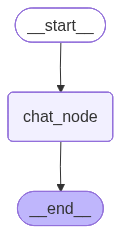

In [6]:
chatbot